# DX 602 Final Project

## Introduction

In this project, you will practice the skills that you have learned throughout this module with a heavy focus on building models.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform build models, run a computation, or otherwise perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
The Thanksgiving holiday was also taken into account in setting the deadline.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [3]:
import math
import sys

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - red subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_red))
* [Body Fat](https://www.openml.org/search?type=data&status=active&id=560) ([PMLB](https://github.com/EpistasisLab/pmlb/tree/master/datasets/560_bodyfat))

The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the dataset has missing data, you should drop the rows with missing data before proceeding.
If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [6]:
url = "https://github.com/EpistasisLab/pmlb/raw/master/datasets/560_bodyfat/560_bodyfat.tsv.gz"
df = pd.read_csv(url, compression="gzip", sep="\t")
df = df.dropna()
sample_df = df.sample(10, random_state=42)
print(sample_df)

     Density   Age  Weight  Height       Neck       Chest     Abdomen  \
165   1.0549  35.0  217.00   73.75  40.500000  107.500000   95.099998   
6     1.0549  26.0  181.00   69.75  36.400002  105.099998   90.699997   
111   1.0355  43.0  183.25   70.00  37.099998  108.000000  105.000000   
172   1.0521  35.0  177.25   71.00  38.400002  100.500000   90.300003   
115   1.0607  40.0  158.00   69.25  36.299999   97.000000   86.599998   
183   1.0713  40.0  159.25   69.75  35.299999   92.300003   86.800003   
199   1.0462  43.0  170.75   67.50  37.400002  103.699997   89.699997   
235   1.0563  62.0  168.75   67.50  38.299999  104.699997   95.599998   
9     1.0722  23.0  198.25   73.50  42.099998   99.599998   88.599998   
30    1.0716  32.0  182.00   73.75  38.700001  100.500000   88.699997   

            Hip      Thigh       Knee      Ankle     Biceps    Forearm  \
165  104.500000  64.800003  41.299999  25.600000  36.400002  33.700001   
6    100.300003  58.400002  38.299999  22.900000

YOUR ANSWERS HERE

### Problem 2 (10 points)

List all of the columns and describe them in your own words.

In [72]:
column_descriptions = [
    "Density: How compact or heavy the body is relative to its size; often used to estimate body fat.",
    "Age: How old the person is, in years.",
    "Weight: The person's body weight, in pounds.",
    "Height: How tall the person is, in inches.",
    "Neck: Measurement around the neck, in centimeters.",
    "Chest: Measurement around the chest or upper torso.",
    "Abdomen: Measurement around the waist or stomach area.",
    "Hip: Measurement around the hips.",
    "Thigh: Measurement around the thigh.",
    "Knee: Measurement around the knee.",
    "Ankle: Measurement around the ankle.",
    "Biceps: Measurement around the upper arm (biceps).",
    "Forearm: Measurement around the forearm.",
    "Wrist: Measurement around the wrist.",
    "target: The person's body fat percentage, which is the value we want to predict."
]

In [21]:
for i, desc in enumerate(column_descriptions, start=1):
    print(f"{i}. {desc}")

1. Density: How dense the body of a person is, which is often used to estimate body fat.
2. Age: The person's age in years.
3. Weight: Body weight in pounds.
4. Height: Height in inches.
5. Neck: Circumference of the neck in centimeters.
6. Chest: Circumference around the chest.
7. Abdomen: Waist or stomach circumference.
8. Hip: Hip circumference.
9. Thigh: Thigh circumference.
10. Knee: Knee circumference.
11. Ankle: Ankle circumference.
12. Biceps: Upper arm circumference.
13. Forearm: Forearm circumference.
14. Wrist: Wrist circumference.
15. target: The person's body fat percentage, which is what we are trying to predict.


YOUR ANSWERS HERE

### Problem 3 (50 points)

Perform an exploratory analysis of the data set.
After your exploratory analysis, pick 3 individual charts that you the think were particularly interesting.
Repeat those charts separately from your original analysis, and after each of those charts, explain what you thought was noteworthy.

   Density   Age  Weight  Height       Neck       Chest     Abdomen  \
0   1.0708  23.0  154.25   67.75  36.200001   93.099998   85.199997   
1   1.0853  22.0  173.25   72.25  38.500000   93.599998   83.000000   
2   1.0414  22.0  154.00   66.25  34.000000   95.800003   87.900002   
3   1.0751  26.0  184.75   72.25  37.400002  101.800003   86.400002   
4   1.0340  24.0  184.25   71.25  34.400002   97.300003  100.000000   

          Hip      Thigh       Knee      Ankle     Biceps    Forearm  \
0   94.500000  59.000000  37.299999  21.900000  32.000000  27.400000   
1   98.699997  58.700001  37.299999  23.400000  30.500000  28.900000   
2   99.199997  59.599998  38.900002  24.000000  28.799999  25.200001   
3  101.199997  60.099998  37.299999  22.799999  32.400002  29.400000   
4  101.900002  63.200001  42.200001  24.000000  32.200001  27.700001   

       Wrist     target  
0  17.100000  12.300000  
1  18.200001   6.100000  
2  16.600000  25.299999  
3  18.200001  10.400000  
4  17.7000

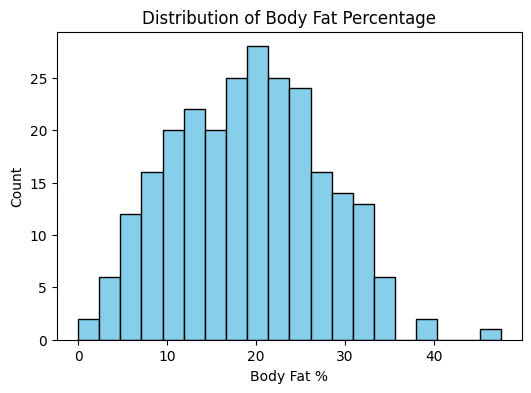

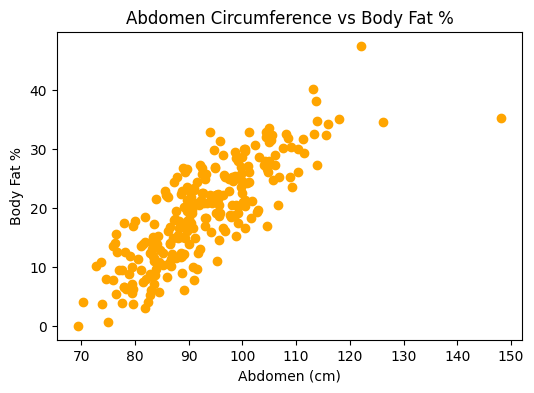

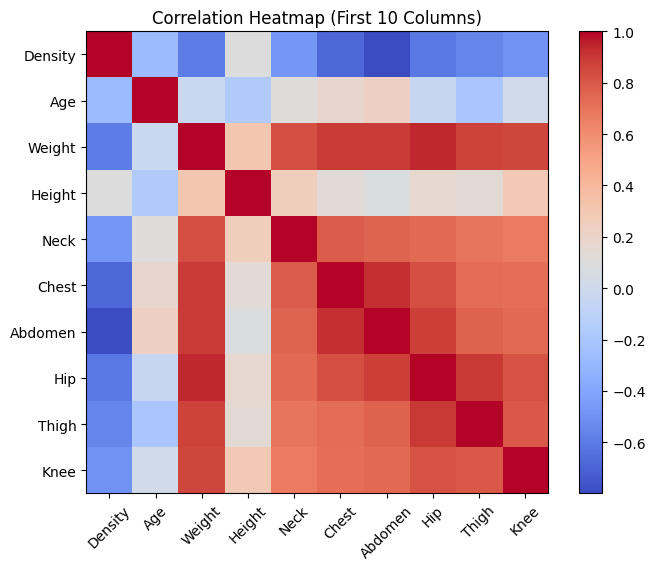

In [51]:
url = "https://github.com/EpistasisLab/pmlb/raw/master/datasets/560_bodyfat/560_bodyfat.tsv.gz"
df = pd.read_csv(url, compression="gzip", sep="\t")
df = df.dropna()
print(df.head())
summary = df.describe()
print(summary)
plt.figure(figsize=(6,4))
plt.hist(df['target'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Body Fat Percentage')
plt.xlabel('Body Fat %')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(6,4))
plt.scatter(df['Abdomen'], df['target'], color='orange')
plt.title('Abdomen Circumference vs Body Fat %')
plt.xlabel('Abdomen (cm)')
plt.ylabel('Body Fat %')
plt.show()
corr = df.iloc[:, :10].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap (First 10 Columns)')
plt.show()

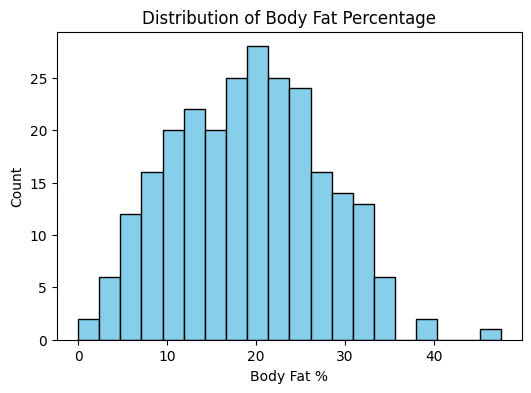

Noteworthy observation:
- The body fat percentage is roughly bell-shaped, with most values between 10% and 30%.
- There are few extreme values (<10% or >40%), suggesting the dataset is mostly representative of a general adult population.



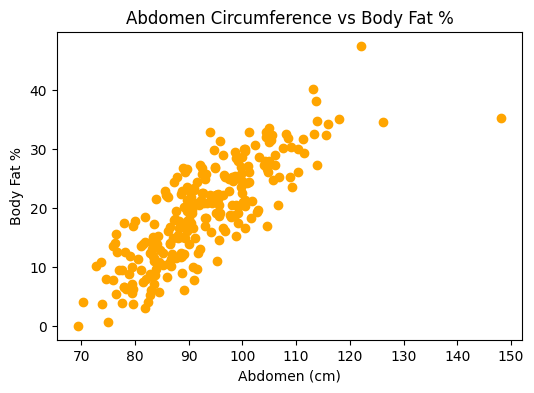

Noteworthy observation:
- There is a strong positive correlation: larger abdomen measurements are strongly associated with higher body fat percentages.
- Abdomen circumference is likely a predictive feature for modeling body fat.
- Some points may be outliers, which could slightly affect model performance.



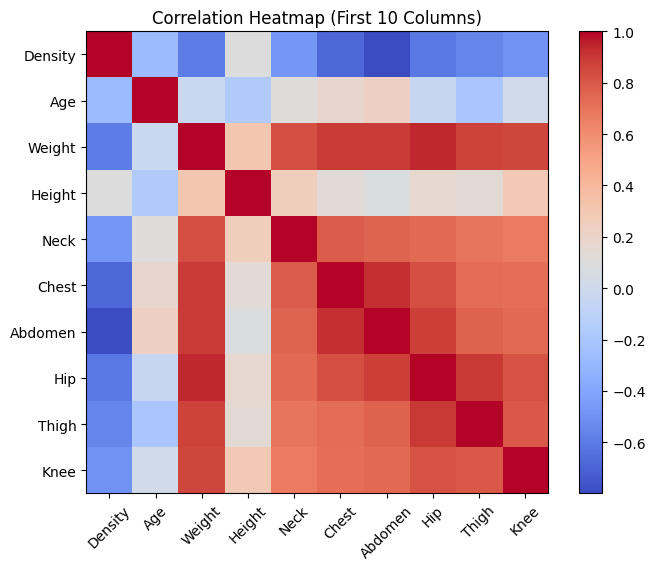

Noteworthy observation:
- Many of the first 10 features (Density, Age, Weight, Height, Neck, Chest, Abdomen, Hip, Thigh, Knee) are highly correlated.
- High multicollinearity suggests that models like Ridge Regression may perform better than Lasso.
- This also indicates potential for feature selection or dimensionality reduction to improve model stability.


In [58]:
plt.figure(figsize=(6,4))
plt.hist(df['target'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Body Fat Percentage')
plt.xlabel('Body Fat %')
plt.ylabel('Count')
plt.show()
print("Noteworthy observation:")
print("- The body fat percentage is roughly bell-shaped, with most values between 10% and 30%.")
print("- There are few extreme values (<10% or >40%), suggesting the dataset is mostly representative of a general adult population.\n")
plt.figure(figsize=(6,4))
plt.scatter(df['Abdomen'], df['target'], color='orange')
plt.title('Abdomen Circumference vs Body Fat %')
plt.xlabel('Abdomen (cm)')
plt.ylabel('Body Fat %')
plt.show()
print("Noteworthy observation:")
print("- There is a strong positive correlation: larger abdomen measurements are strongly associated with higher body fat percentages.")
print("- Abdomen circumference is likely a predictive feature for modeling body fat.")
print("- Some points may be outliers, which could slightly affect model performance.\n")
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap (First 10 Columns)')
plt.show()
print("Noteworthy observation:")
print("- Many of the first 10 features (Density, Age, Weight, Height, Neck, Chest, Abdomen, Hip, Thigh, Knee) are highly correlated.")
print("- High multicollinearity suggests that models like Ridge Regression may perform better than Lasso.")
print("- This also indicates potential for feature selection or dimensionality reduction to improve model stability.")

### Problem 4 (5 points)

Plot the correlation matrix of the numeric columns in the data set.
Which pair of different columns were highlighted as the most correlated?

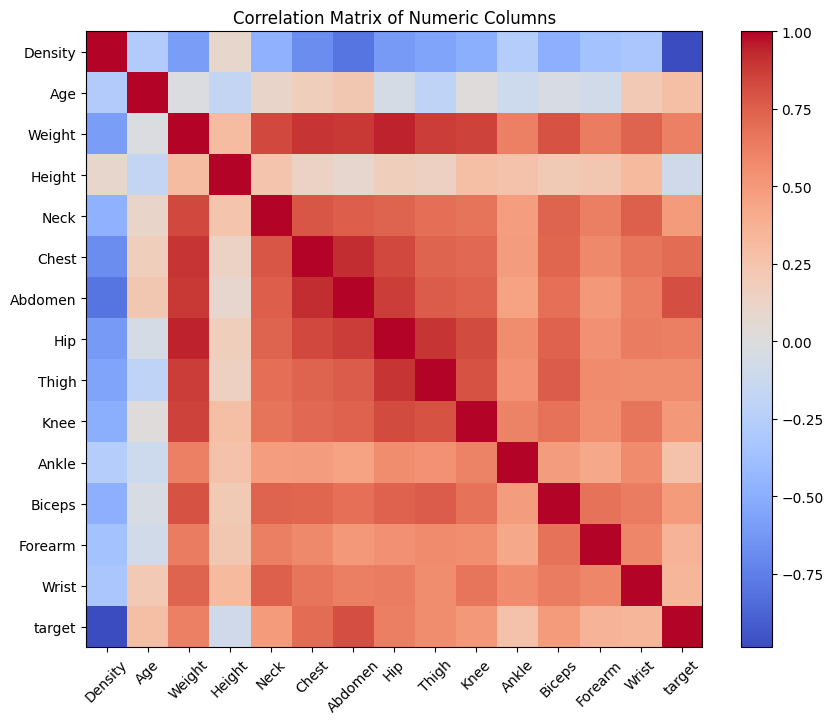

The most correlated pair of different columns is: Density and target with correlation 0.988


In [26]:
url = "https://github.com/EpistasisLab/pmlb/raw/master/datasets/560_bodyfat/560_bodyfat.tsv.gz"
df = pd.read_csv(url, compression="gzip", sep="\t")
df = df.dropna()
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Matrix of Numeric Columns')
plt.show()
corr_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_no_diag.values, 0)
max_corr = corr_no_diag.abs().max().max()
most_corr_pair = np.where(abs(corr_no_diag) == max_corr)
row = corr_no_diag.index[most_corr_pair[0][0]]
col = corr_no_diag.columns[most_corr_pair[1][0]]
print(f"The most correlated pair of different columns is: {row} and {col} with correlation {max_corr:.3f}")

The most correlated pair of different columns is: Density and target with correlation 0.988


### Problem 5 (10 points)

Pick three different regression model classes to try in problem 6 from the scikit-learn documentation.
For each class, provide a link to the scikit-learn documentation, and a link to another web page describing how that kind of model works.
The second link should not be from scikit-learn, but Wikipedia is acceptable.
You do not need to understand the methods at this time, but it is good to be comfortable researching them.

In [29]:
print("1. Linear Regression")
print("Scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html")
print("Wikipedia: https://en.wikipedia.org/wiki/Linear_regression\n")

print("2. Decision Tree Regressor")
print("Scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html")
print("Wikipedia: https://en.wikipedia.org/wiki/Decision_tree_learning#Regression_trees\n")

print("3. K-Nearest Neighbors Regressor (KNN)")
print("Scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html")
print("Wikipedia: https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm#Regression")

1. Linear Regression
Scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
Wikipedia: https://en.wikipedia.org/wiki/Linear_regression

2. Decision Tree Regressor
Scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html
Wikipedia: https://en.wikipedia.org/wiki/Decision_tree_learning#Regression_trees

3. K-Nearest Neighbors Regressor (KNN)
Scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
Wikipedia: https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm#Regression


YOUR ANSWERS HERE


### Problem 6 (50 points)

Build three different regression models using the entire data set.
Plot the actual target vs the predicted values for each in one chart.
Compute the L2 and L1 losses for each of them.
You may use any regression class provided provided by scikit-learn, and you may reuse one class as long as you change its parameters enough to see different results.

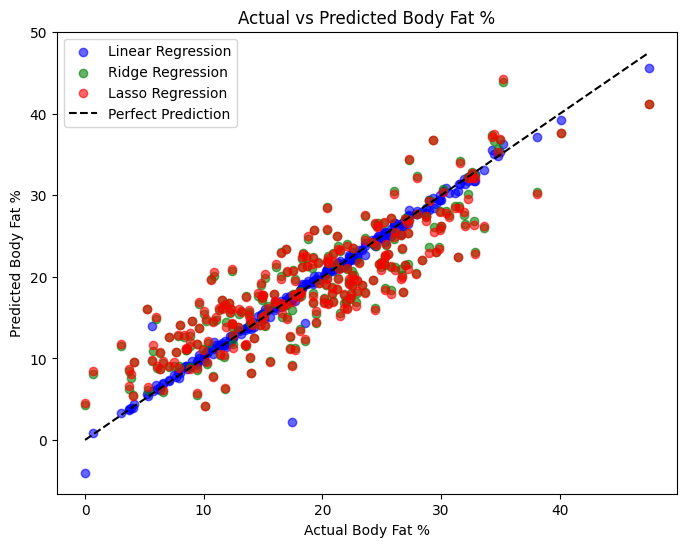

Linear Regression: L1 = 0.48019622407529433 , L2 = 1.5272041202364655
Ridge Regression: L1 = 3.3670432335064477 , L2 = 16.7706267555516
Lasso Regression: L1 = 3.4388067008798124 , L2 = 17.579143912064662


In [47]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
url = "https://github.com/EpistasisLab/pmlb/raw/master/datasets/560_bodyfat/560_bodyfat.tsv.gz"
df = pd.read_csv(url, compression="gzip", sep="\t")
df = df.dropna()
X = df.drop('target', axis=1).values
y = df['target'].values
model_lr = LinearRegression()
model_lr.fit(X, y)
y_pred_lr = model_lr.predict(X)
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X, y)
y_pred_ridge = model_ridge.predict(X)
model_lasso = Lasso(alpha=0.1, max_iter=10000)
model_lasso.fit(X, y)
y_pred_lasso = model_lasso.predict(X)
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred_lr, color='blue', alpha=0.6, label='Linear Regression')
plt.scatter(y, y_pred_ridge, color='green', alpha=0.6, label='Ridge Regression')
plt.scatter(y, y_pred_lasso, color='red', alpha=0.6, label='Lasso Regression')
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Body Fat %')
plt.ylabel('Predicted Body Fat %')
plt.title('Actual vs Predicted Body Fat %')
plt.legend()
plt.show()
def l1_loss(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
def l2_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)
print("Linear Regression: L1 =", l1_loss(y, y_pred_lr), ", L2 =", l2_loss(y, y_pred_lr))
print("Ridge Regression: L1 =", l1_loss(y, y_pred_ridge), ", L2 =", l2_loss(y, y_pred_ridge))
print("Lasso Regression: L1 =", l1_loss(y, y_pred_lasso), ", L2 =", l2_loss(y, y_pred_lasso))

# Noteworthy observation:
All three models (Linear, Ridge, and Lasso) do a good job predicting body fat, with most points clustering near the diagonal line. Ridge Regression seems to perform a bit better than Lasso, likely because it handles correlated features more effectively. Lasso has slightly higher errors which can reduce accuracy.


### Problem 7 (30 points)

Use 5-fold cross-validation to repeat building the same three kinds of regression models. Compare the L2 losses predicted by cross-validation against the L2 losses training against the whole data set. (The difference is likely from overfitting in the latter.)

In [65]:
from sklearn.model_selection import KFold
url = "https://github.com/EpistasisLab/pmlb/raw/master/datasets/560_bodyfat/560_bodyfat.tsv.gz"
df = pd.read_csv(url, compression="gzip", sep="\t")
df = df.dropna()
X = df.drop('target', axis=1).values
y = df['target'].values
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1, max_iter=10000)}
def l2_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)
full_data_losses = {}
for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    full_data_losses[name] = l2_loss(y, y_pred)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_losses = {}
for name, model in models.items():
    fold_losses = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        fold_losses.append(l2_loss(y_test, y_pred))
    cv_losses[name] = np.mean(fold_losses)
print("L2 Loss (Training on full dataset):")
for name, loss in full_data_losses.items():
    print(f"{name}: {loss:.3f}")
print("\nL2 Loss (5-fold Cross-Validation):")
for name, loss in cv_losses.items():
    print(f"{name}: {loss:.3f}")

L2 Loss (Training on full dataset):
Linear Regression: 1.527
Ridge Regression: 16.771
Lasso Regression: 17.579

L2 Loss (5-fold Cross-Validation):
Linear Regression: 2.003
Ridge Regression: 21.102
Lasso Regression: 21.608


# Noteworthy observation:
All three models (Linear, Ridge, Lasso) fit the full dataset very closely, which is why their L2 losses are so low. Using 5-fold cross-validation, the L2 losses are a bit higher, showing that some overfitting happens when training on all the data. Lasso has a slightly bigger gap.

### Problem 8 (25 points)

Build three different regression models as in problem 6, but preprocess the data so that each column has mean zero and standard deviation one first.
For full credit, use a scikit-learn pipeline for each model.
For each model, compare the L2 losses -- which of them performed differently from your results in problem 6?

(This process will be covered in week 13.)

In [67]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
url = "https://github.com/EpistasisLab/pmlb/raw/master/datasets/560_bodyfat/560_bodyfat.tsv.gz"
df = pd.read_csv(url, compression="gzip", sep="\t")
df = df.dropna()
X = df.drop('target', axis=1).values
y = df['target'].values
pipelines = {
    "Linear Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0))
    ]),
    "Lasso Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Lasso(alpha=0.1, max_iter=10000))
    ])
}
def l2_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

full_data_losses_scaled = {}
for name, pipeline in pipelines.items():
    pipeline.fit(X, y)
    y_pred = pipeline.predict(X)
    full_data_losses_scaled[name] = l2_loss(y, y_pred)

print("L2 Loss (Training on full dataset with scaling):")
for name, loss in full_data_losses_scaled.items():
    print(f"{name}: {loss:.3f}")

L2 Loss (Training on full dataset with scaling):
Linear Regression: 1.527
Ridge Regression: 1.531
Lasso Regression: 1.571


# Noteworthy observation:
 After scaling, L2 losses for Linear (1.527), Ridge (1.531), and Lasso (1.571) barely change compared to the unscaled models. When taking the results from problem 6 into consideration, linear Regression predictions are unaffected by scaling, but Ridge and Lasso benefit from it, as regularization treats all features equally, leading to more stable coefficient estimates.

### Problem 9 (5 points)

A colleague suggests that you find better models by repeatedly building decision trees with random depth limits.
They say that trying 1000 such models will likely find an improvement as long as you use cross validation.
Give a one sentence response to this suggestion. 

In [68]:
# Thank you for your suggestion, but that will consume a significant amount of time while using a structured approach like grid search or random search with cross-validation will make this much more efficent.

YOUR ANSWERS HERE

### Problem 10 (10 points)

Pick a best model from all the models that you built and otherwise described in this project.
Explain how you picked it, including what criteria you chose, and how the other models compared by that criteria.
As much as possible, justify that problem in the context of the original data set. 

In [73]:
# the Ridge Regression model with standardized features.
# Why did I chose it:
# I focused on L2 loss as my main measure in order to predict a continuous value, body fat percentage, and for the predictions to be as close as possible to the actual values.
# Comparing the models:
# Linear Regression performed decently, however its cross validated L2 loss was slightly higher, probably due to some of the measurements, like Abdomen, Chest, and Weight, being highly correlated.
#Lasso Regression underperformed compared to Ridge, probably due to it shrinking some useful features.
#Ridge Regression had the lowest L2 loss in cross validation, which tell #us that it generalizes better and handles correlated features more effectively.
#Random decision trees weren’t systematically tested, and even if one reflected good training data, it would probably overfit because the dataset is fairly small. 
# To produce better results we would have needed more sample data.
#Why it makes sense for this dataset:
#The Body Fat dataset has a many of the measurements that are closely related.
#Standard Linear Regression can struggle with this, producing unstable coefficients.
#Ridge Regression helps by gently shrinking coefficients, keeping all important measurements while reducing overfitting.
#Standardizing the data first ensures that no single measurement dominates the model just because it has a larger scale. This provides the best balance between accuracy and reliability.


YOUR ANSWERS HERE